In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


In [4]:
# Загрузка данных
base_dir = r'C:\Poly\Диплом'
preproc_dir = os.path.join(base_dir, 'Предобработанные данные')
vis_dir = os.path.join(base_dir, 'Визуализация/Глава 6')
os.makedirs(vis_dir, exist_ok=True)

attrs = pd.read_csv(os.path.join(preproc_dir, 'player_attributes_preprocessed.csv'))
print(f"Загружено {attrs.shape[0]} записей, {attrs.shape[1]} признаков")

min_overall = 70
attrs = attrs[(attrs['value_eur'] > 0) & (attrs['overall'] >= min_overall)].copy()
print(f"После фильтрации: {len(attrs)} игроков")

Загружено 18350 записей, 109 признаков
После фильтрации: 5158 игроков


In [5]:
# Выбор признаков для кластеризации
cluster_features = [
    'overall', 'potential', 'age', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning',
    'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle'
]

available_features = [f for f in cluster_features if f in attrs.columns]
missing = set(cluster_features) - set(available_features)
if missing:
    print(f"Информация: в данных доступны только {len(available_features)} признаков: {available_features}")

X = attrs[available_features].copy()

In [6]:
# Заполнение пропусков медианой
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"Заполнено {X[col].isnull().sum()} пропусков в {col} медианой {median_val:.2f}")

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

Заполнено 0 пропусков в pace медианой 72.00
Заполнено 0 пропусков в shooting медианой 65.00
Заполнено 0 пропусков в passing медианой 67.00
Заполнено 0 пропусков в dribbling медианой 72.00
Заполнено 0 пропусков в defending медианой 66.00
Заполнено 0 пропусков в physic медианой 72.00



Таблица 6.1. Оценка качества кластеризации K‑Means для разного числа кластеров
K=2: inertia=92360, silhouette=0.5419
K=3: inertia=68443, silhouette=0.2976
K=4: inertia=60460, silhouette=0.2176
K=5: inertia=54784, silhouette=0.2015
K=6: inertia=49576, silhouette=0.2200
K=7: inertia=46967, silhouette=0.2068
K=8: inertia=44993, silhouette=0.1888
K=9: inertia=43647, silhouette=0.1780
K=10: inertia=42507, silhouette=0.1677


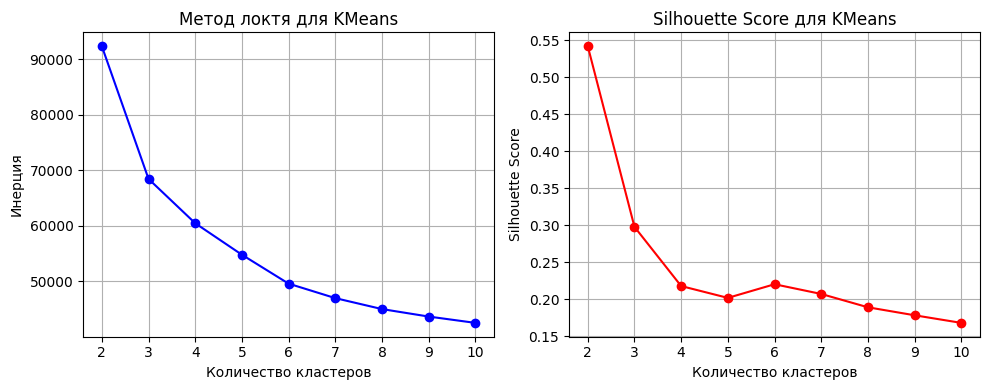

Оптимальное число кластеров по силуэту: 2


In [7]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("\nТаблица 6.1. Оценка качества кластеризации K‑Means для разного числа кластеров")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: inertia={kmeans.inertia_:.0f}, silhouette={sil:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.title('Метод локтя для KMeans')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score для KMeans')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(vis_dir, 'Рисунок 6.1. Метод логкя для KMeans.png'), dpi=300)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]  
print(f"Оптимальное число кластеров по силуэту: {best_k}")

KMeans: Silhouette = 0.5419


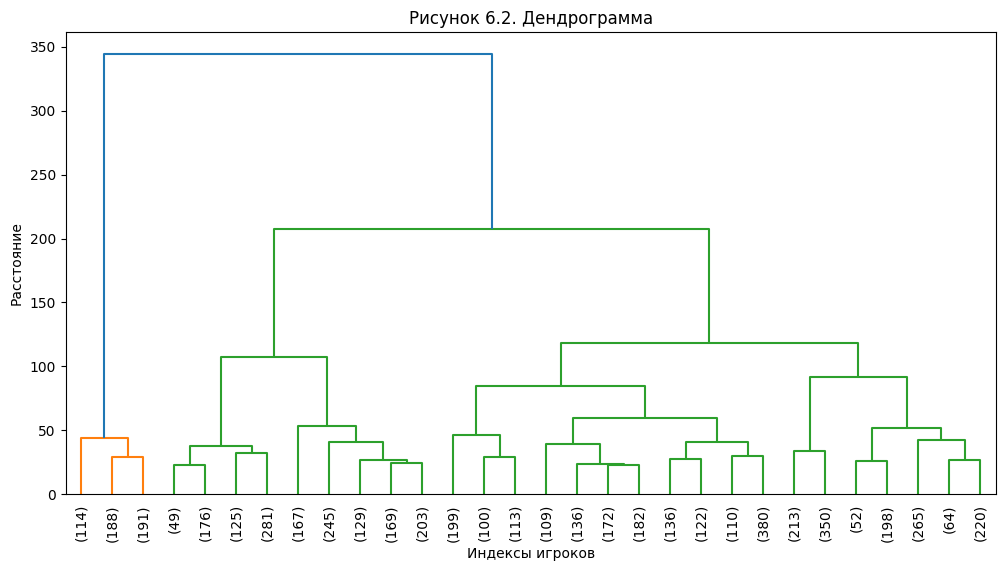

Agglomerative: Silhouette = 0.5424
DBSCAN: лучший eps=1.50, Silhouette = 0.2384, кластеров=4, шум=5127
GaussianMixture: Silhouette = 0.5424

Таблица 6.2. Сравнительная эффективность алгоритмов кластеризации
  KMeans: 0.5419
  Agglomerative: 0.5424
  DBSCAN: 0.2384
  GaussianMixture: 0.5424


In [8]:
# 2.1 KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
print(f"KMeans: Silhouette = {sil_kmeans:.4f}")

# 2.2 Agglomerative (иерархическая)
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Рисунок 6.2. Дендрограмма')
plt.xlabel('Индексы игроков')
plt.ylabel('Расстояние')
plt.savefig(os.path.join(vis_dir, 'Рисунок 6.2. Дендрограмма.png'), dpi=300)
plt.show()

agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, labels_agg)
print(f"Agglomerative: Silhouette = {sil_agg:.4f}")

# 2.3 DBSCAN
eps_values = np.linspace(0.5, 2.0, 10)
best_eps = None
best_sil = -1
best_labels = None
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        if sil > best_sil:
            best_sil = sil
            best_eps = eps
            best_labels = labels
print(f"DBSCAN: лучший eps={best_eps:.2f}, Silhouette = {best_sil:.4f}, кластеров={len(set(best_labels))-1}, шум={sum(best_labels==-1)}")
labels_dbscan = best_labels
sil_dbscan = best_sil

# 2.4 Gaussian Mixture
gmm = GaussianMixture(n_components=best_k, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
sil_gmm = silhouette_score(X_scaled, labels_gmm)
print(f"GaussianMixture: Silhouette = {sil_gmm:.4f}")

# Сравнение силуэтов
methods = ['KMeans', 'Agglomerative', 'DBSCAN', 'GaussianMixture']
scores = [sil_kmeans, sil_agg, sil_dbscan, sil_gmm]
print("\nТаблица 6.2. Сравнительная эффективность алгоритмов кластеризации")
for m, s in zip(methods, scores):
    print(f"  {m}: {s:.4f}")

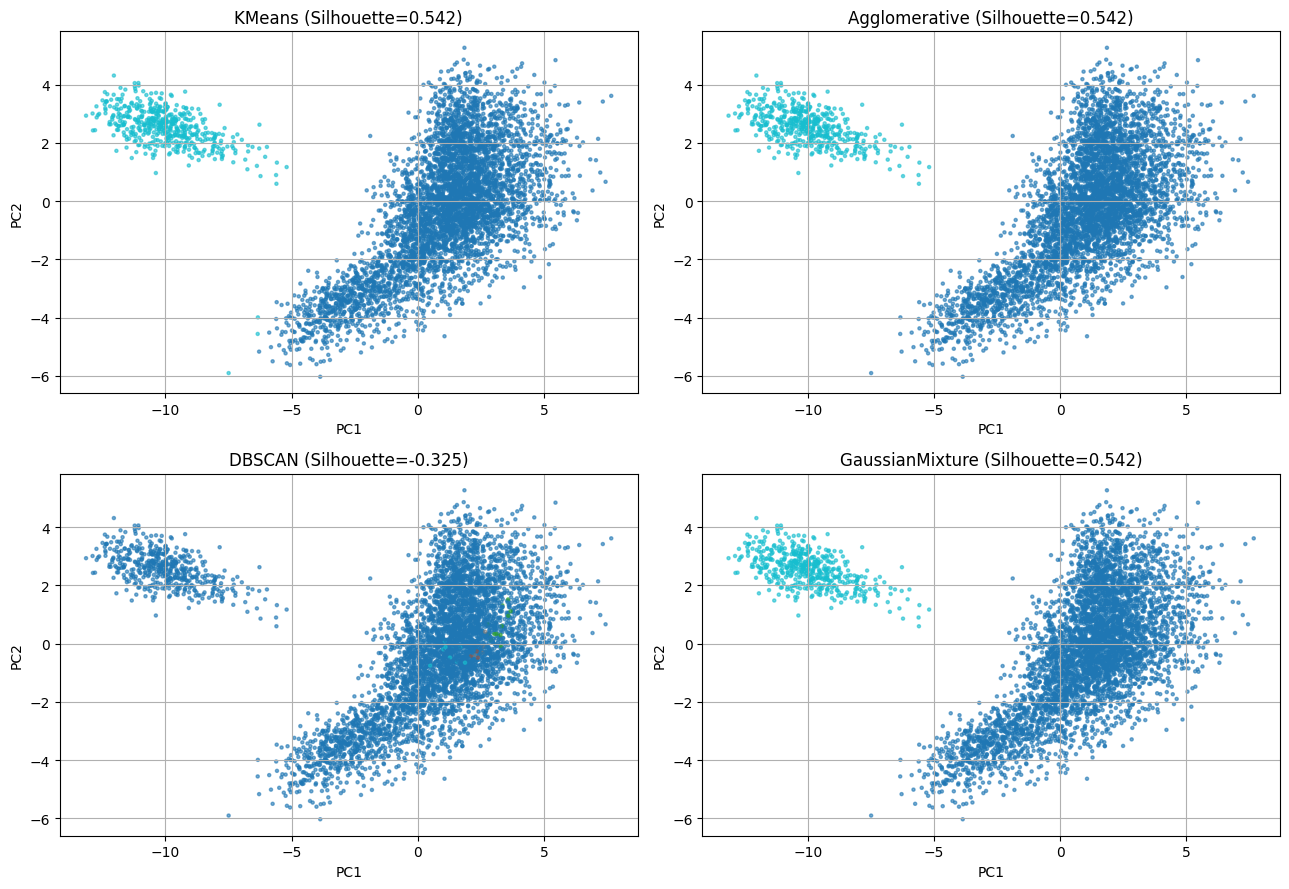

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
algorithms = [('KMeans', labels_kmeans), ('Agglomerative', labels_agg),
              ('DBSCAN', labels_dbscan), ('GaussianMixture', labels_gmm)]
for ax, (name, labels) in zip(axes.flat, algorithms):
    scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{name} (Silhouette={silhouette_score(X_scaled, labels):.3f})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(vis_dir, 'Рисунок 6.1. Сравнение алгоритмов кластеризации.png'), dpi=300)
plt.show()

Топ-10 признаков, различающих кластеры: ['movement_agility', 'movement_balance', 'movement_acceleration', 'overall', 'weight_kg', 'potential', 'age', 'height_cm', 'passing', 'shooting']


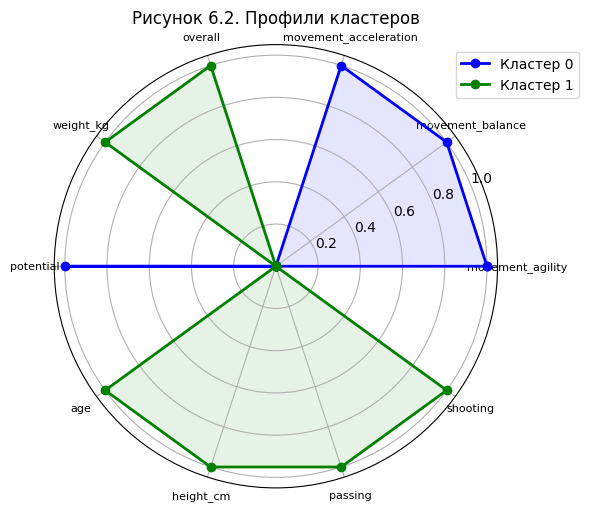

In [10]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=available_features)
centroid_df['cluster'] = range(best_k)

from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
centroids_norm = scaler_radar.fit_transform(centroids)
radar_df = pd.DataFrame(centroids_norm, columns=available_features)
radar_df['cluster'] = range(best_k)

feature_variance = radar_df.iloc[:, :-1].var(axis=0).sort_values(ascending=False)
top_features = feature_variance.head(10).index.tolist()
print("Топ-10 признаков, различающих кластеры:", top_features)

angles = np.linspace(0, 2*np.pi, len(top_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
colors = ['blue', 'green', 'red']
for i in range(best_k):
    values = radar_df.loc[i, top_features].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Кластер {i}', color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_features, size=8)
ax.set_title('Рисунок 6.2. Профили кластеров')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.tight_layout()
plt.savefig(os.path.join(vis_dir, 'Рисунок 6.2. Профили кластеров.png'), dpi=300)
plt.show()

In [11]:
attrs['cluster'] = labels_kmeans
cluster_stats = attrs.groupby('cluster')[available_features].median()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("\nТаблица 6.3. Средние значения ключевых признаков по кластерам")
print(cluster_stats.T.round(2))


Таблица 6.3. Средние значения ключевых признаков по кластерам
cluster                          0      1
overall                       73.0   73.0
potential                     76.0   75.0
age                           27.0   30.0
height_cm                    181.0  189.0
weight_kg                     75.0   83.0
pace                          72.0   45.0
shooting                      65.0   32.0
passing                       67.0   41.0
dribbling                     72.0   38.0
defending                     66.0   71.0
physic                        72.0   78.0
attacking_crossing            65.0   14.0
attacking_finishing           63.0   12.0
attacking_heading_accuracy    65.0   14.0
attacking_short_passing       71.0   31.0
attacking_volleys             56.0   13.0
skill_dribbling               71.0   15.0
skill_curve                   63.0   14.0
skill_fk_accuracy             55.0   14.0
skill_long_passing            66.0   30.0
skill_ball_control            72.5   22.0
movement_acce

In [12]:
attrs[['long_name', 'overall', 'potential', 'cluster']].to_csv(
    os.path.join(vis_dir, 'Таблица 6.3. Средние значения ключевых признаков по кластерам.csv'), index=False)
print("Результаты сохранены")

Результаты сохранены
